# **UPLOAD THE DATASET**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving winequality (1).csv to winequality (1).csv


# **WINE QUALITY MACHINE LEARNING PROJECT**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# **STEP 1: LOAD DATASET**

In [4]:
df = pd.read_csv('winequality (1).csv')

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nDESCRIPTIVE STATISTICS")
print(df.describe())


FIRST 5 ROWS
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      

# **STEP 2: MISSING VALUES & CORRELATION**

In [6]:
print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nCORRELATION WITH QUALITY")
print(df.corr()['quality'].sort_values(ascending=False))


MISSING VALUES
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

CORRELATION WITH QUALITY
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


# **STEP 3: CREATE BINARY TARGET**

In [7]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("\nTARGET DISTRIBUTION")
print(df['quality_label'].value_counts())

df.drop('quality', axis=1, inplace=True)


TARGET DISTRIBUTION
quality_label
0    1382
1     217
Name: count, dtype: int64


# **STEP 4: TRAIN TEST SPLIT**

In [8]:
X = df.drop('quality_label', axis=1)
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **EVALUATION FUNCTION**

In [9]:
def evaluate_model(y_true, y_pred, title):
    print("\n", "="*50)
    print(title)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# **STEP 5: LOGISTIC REGRESSION (UNSCALED)**

In [10]:
lr_unscaled = LogisticRegression(max_iter=10000)

lr_unscaled.fit(X_train, y_train)

pred_unscaled = lr_unscaled.predict(X_test)

evaluate_model(
    y_test,
    pred_unscaled,
    "Logistic Regression (Without Scaling)"
)



Logistic Regression (Without Scaling)
Accuracy : 0.859375
Precision: 0.55
Recall   : 0.23404255319148937
F1 Score : 0.3283582089552239
Confusion Matrix:
[[264   9]
 [ 36  11]]


# **STEP 6: STANDARD SCALER**

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LogisticRegression()

lr_scaled.fit(X_train_scaled, y_train)

pred_scaled = lr_scaled.predict(X_test_scaled)

evaluate_model(
    y_test,
    pred_scaled,
    "Logistic Regression (With Scaling)"
)


Logistic Regression (With Scaling)
Accuracy : 0.865625
Precision: 0.5909090909090909
Recall   : 0.2765957446808511
F1 Score : 0.37681159420289856
Confusion Matrix:
[[264   9]
 [ 34  13]]


# **STEP 7: MODEL COMPARISON**

In [12]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

best_model = None
best_accuracy = 0
best_name = ""

print("\nMODEL COMPARISON")

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)

    print(f"{name}: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_name = name

print("\nBest Model:", best_name)


MODEL COMPARISON
Logistic Regression: 0.8656
KNN: 0.8812
Decision Tree: 0.8719

Best Model: KNN


# **STEP 8: HYPERPARAMETER TUNING**

In [13]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters")
print(grid.best_params_)

best_tree = grid.best_estimator_

pred_tuned = best_tree.predict(X_test_scaled)

evaluate_model(
    y_test,
    pred_tuned,
    "Tuned Decision Tree"
)


Best Parameters
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuned Decision Tree
Accuracy : 0.896875
Precision: 0.7058823529411765
Recall   : 0.5106382978723404
F1 Score : 0.5925925925925926
Confusion Matrix:
[[263  10]
 [ 23  24]]


# **STEP 9: FEATURE IMPORTANCE**


FEATURE IMPORTANCE
                 Feature  Importance
10               alcohol    0.347850
9              sulphates    0.232742
6   total sulfur dioxide    0.113440
1       volatile acidity    0.086257
5    free sulfur dioxide    0.076413
8                     pH    0.058710
4              chlorides    0.036915
0          fixed acidity    0.028199
3         residual sugar    0.019474
2            citric acid    0.000000
7                density    0.000000


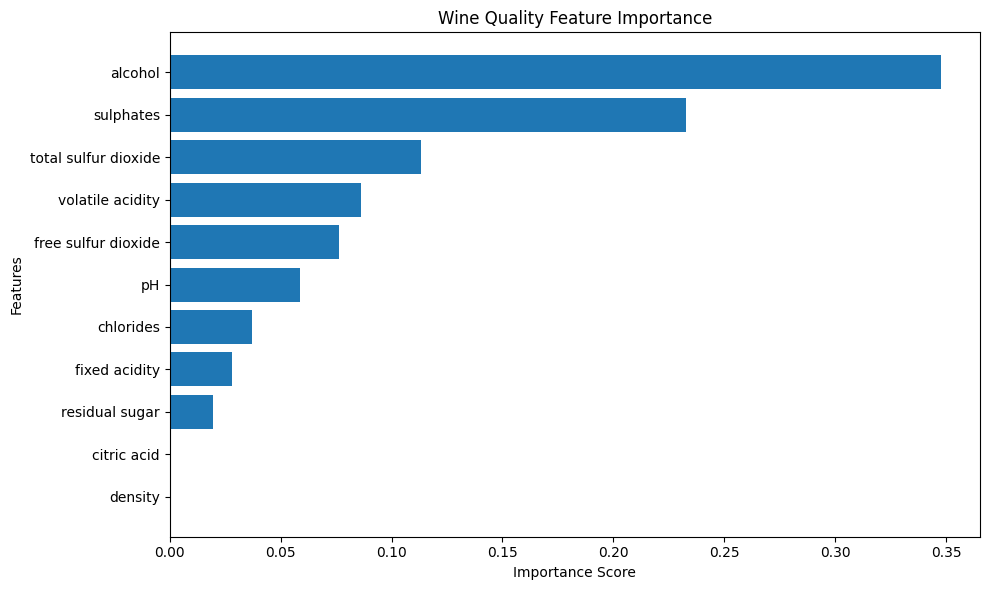

In [14]:
importance = best_tree.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFEATURE IMPORTANCE")
print(feature_df)

plt.figure(figsize=(10,6))
plt.barh(
    feature_df['Feature'][::-1],
    feature_df['Importance'][::-1]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Wine Quality Feature Importance")
plt.tight_layout()
plt.show()

# **Conclusion:**
1. Loaded and analyzed the Wine Quality dataset.

2. Created a binary target variable (quality_label).

3. Trained Logistic Regression before and after scaling.

4. Compared Logistic Regression, KNN, and Decision Tree.

5. Selected the best-performing model.

6. Applied GridSearchCV for hyperparameter tuning.

7. Evaluated the optimized model using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

8. Performed Feature Importance Analysis to identify the most influential wine characteristics affecting quality.





